In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import numpy as np
import matplotlib.pyplot as plt

# Barebones attention
This notebook implements barebones attention methods for next-token prediction in an artificial timeseries dataset.


## Dataset
Let's first start with the dataset. This is generated from a noisy sinusoid, from which we cut `seq_len` timepoints as `X` and add the next timepoint as `y` - our target label.


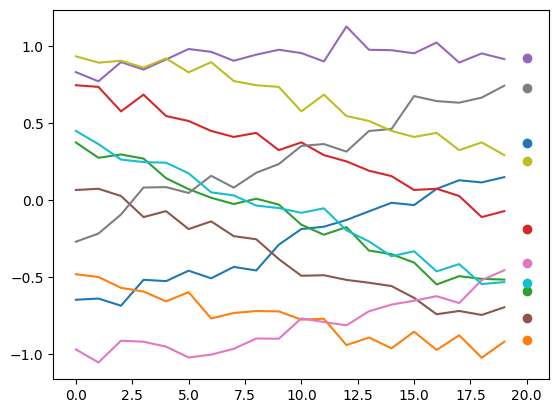

In [ ]:
class SineDataset(Dataset):
    def __init__(self, seq_len=10, total_steps=1000):
        x = np.linspace(0, 100, total_steps)
        # the scale of the noise level [0.05 here] is important
        # too much and the model will not learn from only a few timepoints
        data = np.sin(x) + 0.05 * np.random.randn(total_steps)
        self.seq_len, self.data = seq_len, data.astype(np.float32)

    def __len__(self):
        return len(self.data) - self.seq_len

    def __getitem__(self, i):
        # cut timepoints from sinusoid
        X = torch.tensor(self.data[i : i + self.seq_len]).unsqueeze(-1)
        # add next timepoint as target label
        y = torch.tensor(self.data[i + self.seq_len])
        return X, y

# create dataset
seq_len = 20
dataset = SineDataset(seq_len, total_steps=2000)

# define pytorch dataloader to gather data from dataset
loader = DataLoader(dataset, batch_size=32, shuffle=True)

sample_X, sample_y = next(iter(loader))

# plot 10 samples and their target
plt.figure(1)
for i in np.arange(10):
  line1, = plt.plot(sample_X[i][:],label=str(i))
  color1 = line1.get_color()
  plt.plot(seq_len,sample_y[i],'o',label=str(i),color=color1)

## Encoder - Attention - Decoder model

We first implement the "classic" attention, modeled after seq2seq attention, in which the encoder provides a representation of the timeseries so far, the attention delivers some kind of context to the decoder, which then predicts the target.

The implementation here uses LSTM blocks, however, standard RNNs could also of course be used.

The implementation also uses the query, key, value approach popularized by the Transformer paper. Again, other types of contextual computation could be used.

In [ ]:
class Encoder(nn.Module):
    def __init__(self, input_dim, hidden_dim):
        super(Encoder, self).__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, batch_first=True)

    def forward(self, x):
        output, (h_n, c_n) = self.lstm(x)  # output: (batch, seq_len, hidden_dim)
        return output, (h_n[-1], c_n[-1])

In [ ]:
class Attention(nn.Module):
    def __init__(self, hidden_dim):
        super(Attention, self).__init__()
        self.query_proj = nn.Linear(hidden_dim, hidden_dim)
        self.key_proj = nn.Linear(hidden_dim, hidden_dim)
        self.value_proj = nn.Linear(hidden_dim, hidden_dim)
        self.softmax = nn.Softmax(dim=2)

    def forward(self, encoder_outputs, decoder_hidden):
        """
        encoder_outputs: (batch, seq_len, hidden_dim)
        decoder_hidden: (batch, hidden_dim)
        """
        keys = self.key_proj(encoder_outputs)  # (batch, seq_len, hidden)
        values = self.value_proj(encoder_outputs)  # (batch, seq_len, hidden)
        query = self.query_proj(decoder_hidden).unsqueeze(1)  # (batch, 1, hidden)

        # compute attention scores and weights and normalize
        scores = torch.bmm(query, keys.transpose(1, 2)) / np.sqrt(keys.size(-1)) # (batch, 1, seq_len)
        weights = self.softmax(scores)  # (batch, 1, seq_len)

        # compute weighted sum of values
        attended = torch.bmm(weights, values)  # (batch, 1, hidden)
        return attended.squeeze(1), weights.squeeze(1)

In [ ]:
class Decoder(nn.Module):
    def __init__(self, hidden_dim):
        super(Decoder, self).__init__()
        self.rnn = nn.LSTMCell(hidden_dim, hidden_dim)
        self.fc = nn.Linear(hidden_dim * 2, 1)  # concat context + hidden

    def forward(self, context, hidden, cell):
        h, c = self.rnn(context, (hidden, cell))  # simulate decoding step
        out = self.fc(torch.cat([h, c], dim=1))
        return out.squeeze(1), h, c

In [ ]:
class Seq2SeqAttn(nn.Module):
    def __init__(self, input_dim, hidden_dim):
        super().__init__()
        self.enc = Encoder(input_dim, hidden_dim)
        self.attn = Attention(hidden_dim)
        self.dec = Decoder(hidden_dim)

    def forward(self, x):
        enc_out, (h, c) = self.enc(x)
        # note that attention only receives the hidden state to generate the
        # context vector
        ctx, _ = self.attn(enc_out, h)
        pred, _, _ = self.dec(ctx, h, c)
        return pred

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

# instantiate model using 1 input dimension and 64 hidden dimensions
model = Seq2SeqAttn(1, 64).to(device)

# simple MSE loss is sufficient to predict continuous variable here
opt = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()

# train for 20 epochs using standard vanilla training loop
epochs = 20
for epoch in range(epochs):
    epoch_loss = 0.0
    model.train()
    for X, y in loader:
        X, y = X.to(device), y.to(device)
        opt.zero_grad()
        pred = model(X)
        loss = loss_fn(pred, y)
        loss.backward()
        opt.step()
        epoch_loss += loss.item() * X.size(0)
    print(f"Epoch {epoch+1}/{epochs}, Loss: {epoch_loss/len(dataset):.6f}")

cpu
Epoch 1/30, Loss: 0.201945
Epoch 2/30, Loss: 0.019967
Epoch 3/30, Loss: 0.004058
Epoch 4/30, Loss: 0.003719
Epoch 5/30, Loss: 0.004006
Epoch 6/30, Loss: 0.003588
Epoch 7/30, Loss: 0.003629
Epoch 8/30, Loss: 0.003414
Epoch 9/30, Loss: 0.003606
Epoch 10/30, Loss: 0.003650
Epoch 11/30, Loss: 0.003432
Epoch 12/30, Loss: 0.003513
Epoch 13/30, Loss: 0.003674
Epoch 14/30, Loss: 0.003739
Epoch 15/30, Loss: 0.003502
Epoch 16/30, Loss: 0.003297
Epoch 17/30, Loss: 0.003290
Epoch 18/30, Loss: 0.003434
Epoch 19/30, Loss: 0.003325
Epoch 20/30, Loss: 0.003443
Epoch 21/30, Loss: 0.003248
Epoch 22/30, Loss: 0.003464
Epoch 23/30, Loss: 0.003281
Epoch 24/30, Loss: 0.003547
Epoch 25/30, Loss: 0.003259
Epoch 26/30, Loss: 0.003332
Epoch 27/30, Loss: 0.003278
Epoch 28/30, Loss: 0.003998
Epoch 29/30, Loss: 0.003424
Epoch 30/30, Loss: 0.003164


## Evaluation

Using a standard MSE loss and a small number of hidden states, our model should be able to train well. Note, that the noise and `seq_len` parameters are important in defining how well the model can predict our target.

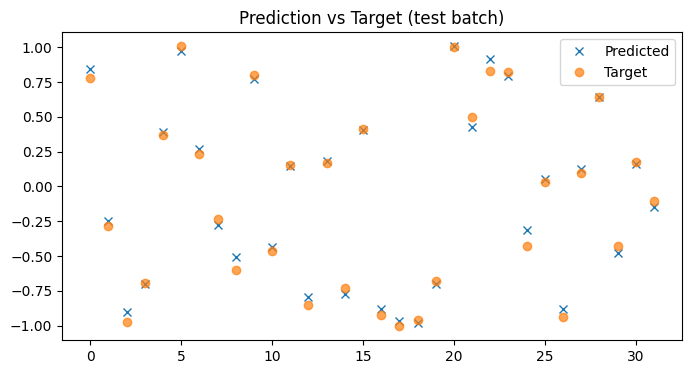

In [ ]:
model.eval()
# note that this is from the training data, since we didn't split off test
test_X, test_y = next(iter(loader))

# get prediction and plot
with torch.no_grad():
    p = model(test_X.to(device)).cpu().numpy()
plt.figure(figsize=(8,4))
plt.plot(p, 'x',label="Predicted")
plt.plot(test_y.numpy(), 'o',label="Target", alpha=0.7)
plt.legend()
plt.title("Prediction vs Target (test batch)")
plt.show()

Let's try to visualize the attention weights that were generated by our model in this run to see at which point in an input timeseries the model would put attention on.

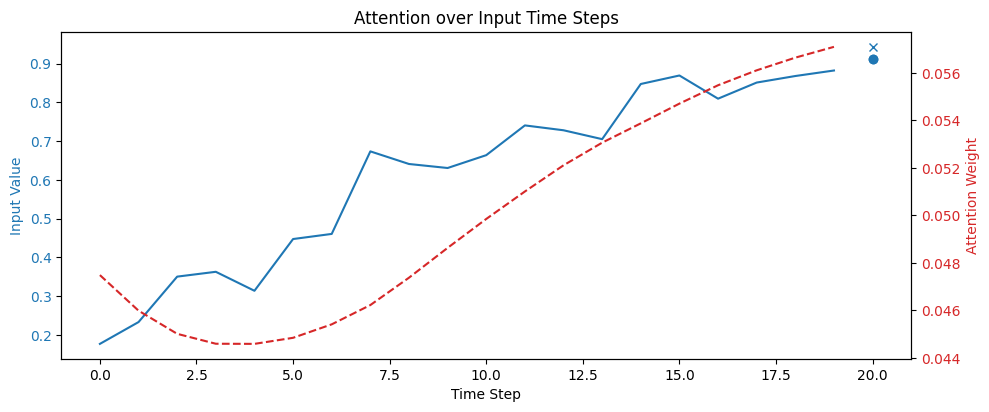

In [ ]:
model.eval()
test_X, test_y = next(iter(loader))
test_X = test_X.to(device)
test_sample = test_X[2].unsqueeze(0)  # shape: (1, seq_len, 1)

with torch.no_grad():
    # Forward through encoder
    enc_out, (h, c) = model.enc(test_sample)
    # Get attention context and weights
    ctx, weights = model.attn(enc_out, h)
    # Get prediction from decoder
    pred, _, _ = model.dec(ctx, h, c)

# Plot input time series and attention weights
input_series = test_sample[0, :, 0].cpu().numpy()
target_point = test_y[2].cpu().numpy()
pred_point = pred.cpu().numpy()
attn_weights = weights[0].cpu().numpy()

fig, ax1 = plt.subplots(figsize=(10, 4))

color = 'tab:blue'
ax1.set_xlabel('Time Step')
ax1.set_ylabel('Input Value', color=color)
ax1.plot(input_series, color=color, label='Input Time Series')
ax1.plot(seq_len,target_point,'x',color=color,label='Target Time Point')
ax1.plot(seq_len,pred_point,'o',color=color,label='Predicted Time Point')

ax1.plot(seq_len,pred_point,'o',color=color,label='Predicted Time Point')
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()  # instantiate a second axis that shares the same x-axis
color = 'tab:red'
ax2.set_ylabel('Attention Weight', color=color)
ax2.plot(attn_weights, color=color, linestyle='--', label='Attention Weights')
ax2.tick_params(axis='y', labelcolor=color)

fig.tight_layout()
plt.title("Attention over Input Time Steps")
plt.show()


## Single-head self attention

The previous model was based on the seq2seq RNN-type attention. The seminal Transformer paper, however, used self attention (with multiple heads) to achieve unprecedented performance in next-token prediction in the language domain.

Let's implement a barebones single-head version of this here and try to repeat the task of next-token prediction on the sinusoid timeseries as well.

In [ ]:
class SingleHeadSelfAttention(nn.Module):
    def __init__(self, embed_dim):
        super().__init__()
        self.embed_dim = embed_dim
        # Q, K, V and scale normalization
        self.query = nn.Linear(embed_dim, embed_dim)
        self.key = nn.Linear(embed_dim, embed_dim)
        self.value = nn.Linear(embed_dim, embed_dim)
        self.scale = np.sqrt(embed_dim)

        # store weights for visualization
        self.latest_attn_weights = None

    def forward(self, x):
        Q = self.query(x)
        K = self.key(x)
        V = self.value(x)

        # same computation as before
        attn_scores = torch.bmm(Q, K.transpose(1, 2)) / self.scale  # (B, S, S)
        attn_weights = torch.softmax(attn_scores, dim=-1)           # (B, S, S)

        # store for plotting
        self.latest_attn_weights = attn_weights.detach().cpu()

        output = torch.bmm(attn_weights, V)  # (B, S, D)
        return output, attn_weights

In [ ]:
class SelfAttentionBlock(nn.Module):
    def __init__(self, embed_dim):
        super().__init__()
        self.attn = SingleHeadSelfAttention(embed_dim)
        # we add layer normalization to stabilize training [it normalizes
        # variance]
        self.norm = nn.LayerNorm(embed_dim)
        # and an output non-linearity
        self.ff = nn.Sequential(
            nn.Linear(embed_dim, embed_dim * 2),
            nn.ReLU(),
            nn.Linear(embed_dim * 2, embed_dim)
        )
        self.norm2 = nn.LayerNorm(embed_dim)

    def forward(self, x):
        attn_out, _ = self.attn(x)
        # note the addition of terms for residual connections (see ResNet)
        # this helps the Transformer to learn additive, rather than absolute
        # levels in the input data
        x = self.norm(x + attn_out)
        ff_out = self.ff(x)
        # note the addition of terms again
        return self.norm2(x + ff_out)


## Positional encoding

Now to one of the core requirements during self-attention for transfomers. The query-key-value mechanism that distributes attention is invariant under input permutation, which means that inside the current attention mechanism, the information about temporal ordering is lost.

This is, however, exactly one of the important parts of our modeling requirements (we are modeling timeseries!), and so we use positional encoding to force the transformer to learn the position of each token in the input.

The standard encoding is fixed and uses a sinusoidal structure to add a unique offset to each token in the input of length
`seq_len` and depth `embed_dim`.

In [ ]:
def get_sinusoidal_encoding(seq_len, embed_dim):
    position = np.arange(seq_len)[:, np.newaxis]         # (seq_len, 1)
    div_term = np.exp(np.arange(0, embed_dim, 2) * (-np.log(10000.0) / embed_dim))  # (embed_dim/2,)

    pe = np.zeros((seq_len, embed_dim))
    pe[:, 0::2] = np.sin(position * div_term)  # even dims
    pe[:, 1::2] = np.cos(position * div_term)  # odd dims
    return torch.tensor(pe, dtype=torch.float32)  # (seq_len, embed_dim)

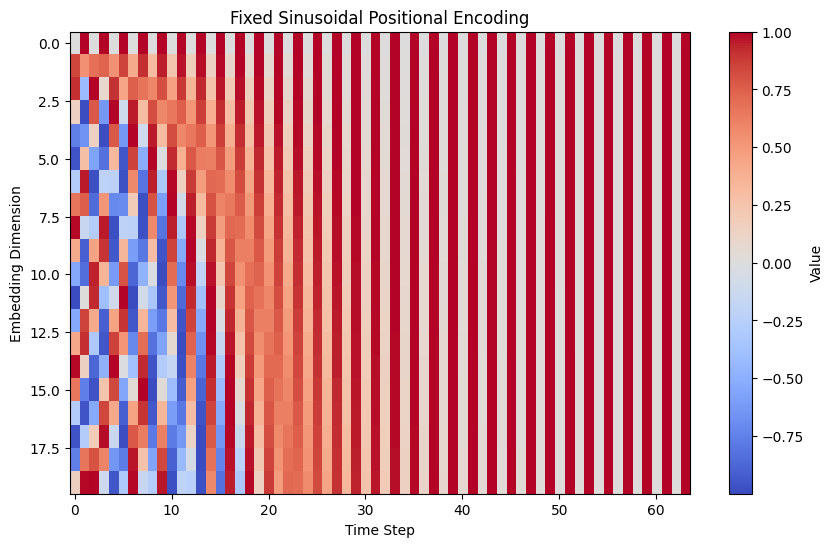

In [ ]:
plt.figure(figsize=(10, 6))
plt.imshow(get_sinusoidal_encoding(20,64), cmap="coolwarm", aspect="auto")
plt.colorbar(label="Value")
plt.title("Fixed Sinusoidal Positional Encoding")
plt.xlabel("Time Step")
plt.ylabel("Embedding Dimension")
plt.show()

## Learned positional encoding

Our base transformer class holds a switch for learning this positional encoding - we then simply add this as a layer of learnable parameters.

The transformer starts with an embedding layer to which the positional encoding is added. We then go through one self-attention block (with one head) and pool our results across time for prediction.

In [ ]:
class SelfAttentionTimeSeries(nn.Module):
    def __init__(self, input_dim=1, embed_dim=64, seq_len=20, learned_pos=False):
        super().__init__()
        self.embed = nn.Linear(input_dim, embed_dim)

        if (learned_pos==True):
          # learned positional encoding
          self.pos = nn.Parameter(torch.randn(1, seq_len, embed_dim))
        else:
          # fixed positional encoding
          pe = get_sinusoidal_encoding(seq_len, embed_dim)
          self.register_buffer("pos", pe.unsqueeze(0))  # shape: (1, seq_len, embed_dim)

        # extension to multiple heads would need something like:
        # SelfAttentionBlock(embed_dim, n_heads) here
        self.attn_block = SelfAttentionBlock(embed_dim)
        self.output = nn.Sequential(
            nn.Linear(embed_dim, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        x = self.embed(x) + self.pos[:, :x.size(1), :]
        x = self.attn_block(x)         # (B, seq_len, embed_dim)
        x = torch.mean(x,dim=1)             # Global average pooling over time
        return self.output(x).squeeze(1)  # Final prediction (next step)

NameError: name 'nn' is not defined

In [ ]:
# training loop is identical to before, like is evaluation
model = SelfAttentionTimeSeries(seq_len=seq_len, learned_pos=False).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()

epochs = 20
for epoch in range(epochs):
    model.train()
    total_loss = 0
    for X, y in loader:
        X, y = X.to(device), y.to(device)
        pred = model(X)
        loss = loss_fn(pred, y)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * X.size(0)
    print(f"Epoch {epoch+1}: Loss = {total_loss / len(dataset):.6f}")

Epoch 1: Loss = 0.060093
Epoch 2: Loss = 0.004408
Epoch 3: Loss = 0.004104
Epoch 4: Loss = 0.004279
Epoch 5: Loss = 0.004624
Epoch 6: Loss = 0.004050
Epoch 7: Loss = 0.003947
Epoch 8: Loss = 0.003869
Epoch 9: Loss = 0.003682
Epoch 10: Loss = 0.003724
Epoch 11: Loss = 0.003697
Epoch 12: Loss = 0.003721
Epoch 13: Loss = 0.003587
Epoch 14: Loss = 0.003697
Epoch 15: Loss = 0.003449
Epoch 16: Loss = 0.004053
Epoch 17: Loss = 0.003677
Epoch 18: Loss = 0.003250
Epoch 19: Loss = 0.003257
Epoch 20: Loss = 0.003111


Our model should learn equally well compared to the seq2seq approach.

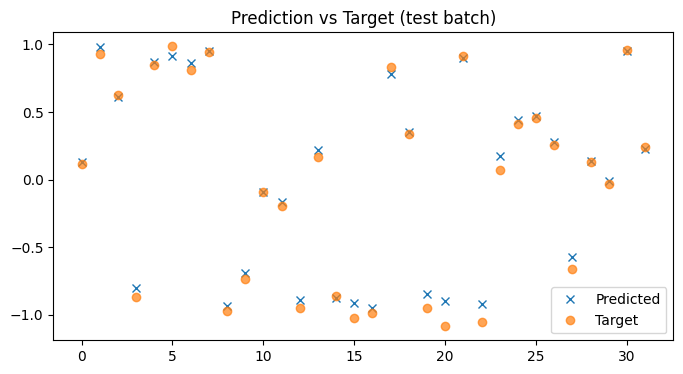

In [ ]:
model.eval()
test_X, test_y = next(iter(loader))
with torch.no_grad():
    p = model(test_X.to(device)).cpu().numpy()
plt.figure(figsize=(8,4))
plt.plot(p, 'x',label="Predicted")
plt.plot(test_y.numpy(), 'o',label="Target", alpha=0.7)
plt.legend()
plt.title("Prediction vs Target (test batch)")
plt.show()

## Attention visualization

Depending on the training run, we can now visualize the attention weights from the self-attention blocks.

Note, that this pattern may change depending on
- training run
- learned versus fixed positional encoding

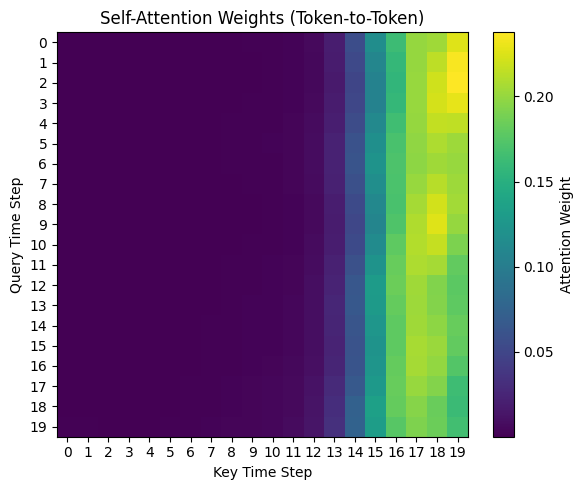

In [ ]:
# attention visualization
model.eval()
with torch.no_grad():
    test_X, test_y = next(iter(loader))
    test_X = test_X.to(device)
    model(test_X)  # trigger forward pass

# access attention weights from the first sample
attn_weights = model.attn_block.attn.latest_attn_weights[0]  # (seq_len, seq_len)

plt.figure(figsize=(6, 5))
plt.imshow(attn_weights, cmap="viridis", aspect="auto")
plt.colorbar(label="Attention Weight")
plt.title("Self-Attention Weights (Token-to-Token)")
plt.xlabel("Key Time Step")
plt.ylabel("Query Time Step")
plt.xticks(ticks=range(seq_len))
plt.yticks(ticks=range(seq_len))
plt.tight_layout()
plt.show()

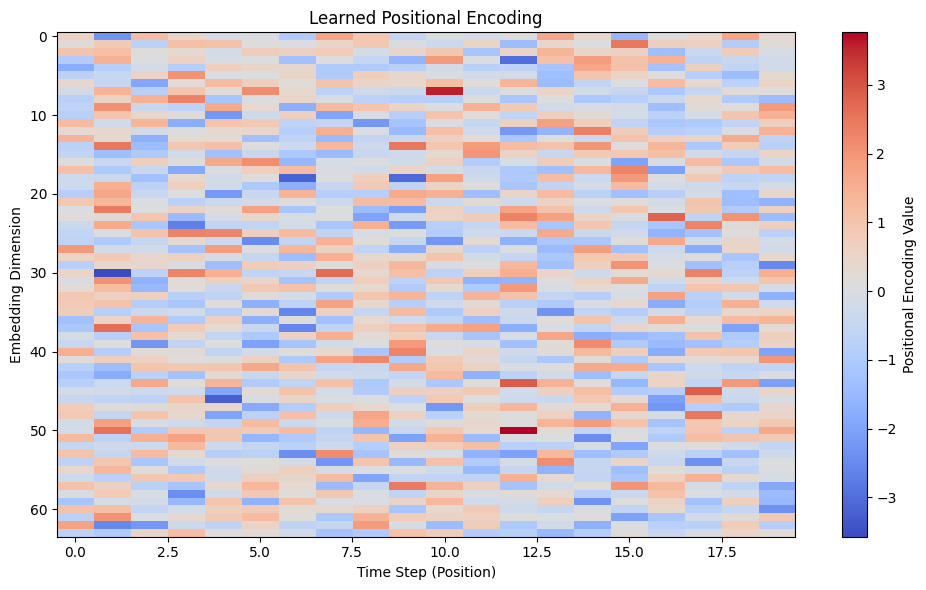

In [ ]:
# visualize learned positional encoding
model.eval()
pos_encoding = model.pos.detach().cpu().squeeze(0).numpy()  # shape: (seq_len, embed_dim)

plt.figure(figsize=(10, 6))
plt.imshow(pos_encoding.T, aspect='auto', cmap='coolwarm')
plt.colorbar(label="Positional Encoding Value")
plt.title("Learned Positional Encoding")
plt.xlabel("Time Step (Position)")
plt.ylabel("Embedding Dimension")
plt.tight_layout()
plt.show()


## Pytorch version

If you want it quick and easy, you can simply use Pytorch's own MHSA block like so:

In [ ]:
class SelfAttentionBlock(nn.Module):
    def __init__(self, embed_dim, n_heads):
        super().__init__()
        self.attn = nn.MultiheadAttention(embed_dim, n_heads, batch_first=True)
        self.norm = nn.LayerNorm(embed_dim)
        self.ff = nn.Sequential(
            nn.Linear(embed_dim, embed_dim * 2),
            nn.ReLU(),
            nn.Linear(embed_dim * 2, embed_dim)
        )
        self.norm2 = nn.LayerNorm(embed_dim)

    def forward(self, x):
        attn_out, _ = self.attn(x, x, x)
        x = self.norm(x + attn_out)
        ff_out = self.ff(x)
        return self.norm2(x + ff_out)

